In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from wordcloud import WordCloud
from collections import defaultdict
import spacy
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from tqdm.auto import tqdm
tqdm.pandas()

In [4]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

In [5]:
nlp = spacy.blank("es")

In [6]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        if t in JIBARO_WORDS + JIBARO_WORDS + CAMPESINO_WORDS:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [7]:
data_df = pd.read_pickle('relevant_docs_df.pkl')
data_df['decade'] = (data_df['year'].astype(int) // 10) * 10

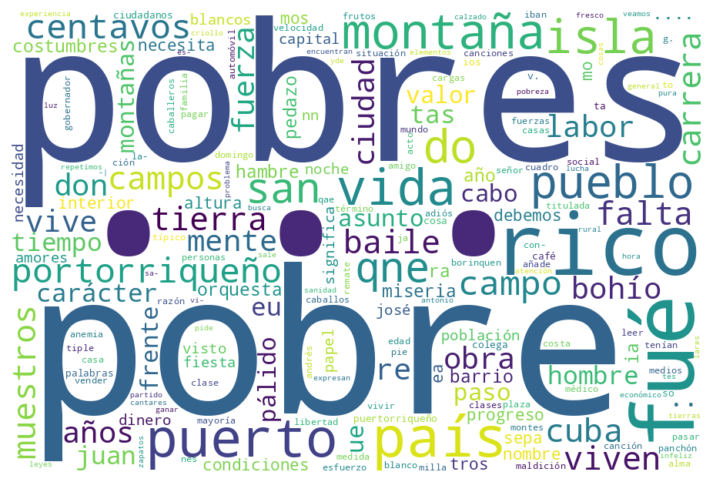

In [316]:
selected_df = data_df.loc[
    (data_df['relevant_gibar_doc'] | data_df['relevant_gibar_doc'] |data_df['relevant_campesin_doc'])
]

tfs = get_term_freqs(selected_df['surrounding_text_jibar'])
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [9]:
nlp = spacy.load("es_core_news_sm")

In [292]:
selected_df['year']

'1921'

In [317]:
text_processed = selected_df['text_cleaned'].progress_apply(lambda s: nlp(s.replace('\n', ' ').replace('-','')))

  0%|          | 0/6353 [00:00<?, ?it/s]

In [318]:
def get_freq(words, exclusions=None):
    frqs = defaultdict(int)
    for w in words:
        if w in nlp.Defaults.stop_words or w in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(w) < 2:
            continue
        if exclusions and w.lower() in exclusions:
            continue
        frqs[w] += 1
    return frqs

def generate_ngrams(doc, n=2):
    tokens = [token.text for token in doc if not token.is_punct]
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

In [319]:
sentences = []
BUFFER = 10
for doc in text_processed:
    for t in doc:
        if t.lower_ in CAMPESINO_WORDS +JIBARO_WORDS + GIBARO_WORDS:
            min_span = max(0, t.i - BUFFER)
            max_span = min(len(doc), t.i + BUFFER)
            if len(t.sent) > (max_span-min_span):
                sentences.append(doc[min_span:max_span])
            else:
                sentences.append(t.sent)

In [320]:
len(sentences)

7751

# POS and N-Gram Based Word CLoud

In [298]:
dictionary = set()
with open('spanish_frequency_dictionary.txt', 'r') as f:
    for l in f.readlines():
        dictionary.add(l.split()[0])

In [299]:
dictionary.add('portorriqueas')

In [321]:
def are_all_stopwords(words):
    sw_count = 0
    for w in words:
        if w in nlp.Defaults.stop_words:
            sw_count += 1
    return sw_count == len(words)
    
def compute_word_cloud_frequencies(sentences, exclusions=[]):
    
    ignored_words = []
    pos_toks = defaultdict(list)
    n_grams = []
    for s in sentences:
        for t in s:
            if len(t) > 2 and t.lower_ not in exclusions:
                if t.lower_ in dictionary:
                    pos_toks[t.pos_].append(t.lower_)
                else:
                    ignored_words.append(t.lower_)

        
        words = [
            token.text for token in s 
                if 
                    not token.is_punct and 
                    not token.is_space and
                    token.lower_ in dictionary and
                    token.lower_ not in nlp.Defaults.stop_words and 
                    token.lower_ not in exclusions
                    
        ] 
        if len(words) > 3:
            bigrams = [' '.join(t) for t in zip(words, words[1:]) if not are_all_stopwords(t)]
            # Generate Trigrams
            trigrams = [' '.join(t) for t in zip(words, words[1:], words[2:]) if not are_all_stopwords(t)]
            
            n_grams.extend(bigrams)
            n_grams.extend(trigrams)
    n_gram_counts = pd.Series(n_grams).value_counts()
    n_gram_counts = n_gram_counts[n_gram_counts > 1].to_dict()
    

    

    tfs = get_freq(pos_toks['NOUN'] + pos_toks['ADJ'])
    tfs = tfs | n_gram_counts

    tfs_filtered = {k:v for k, v in tfs.items() if k not in exclusions}
    
    return {
        'tfs': tfs_filtered,
        'n_grams': n_grams,
        'pos_toks': pos_toks,
        'ignored_words': ignored_words
    }
    

In [322]:
exclusions = CAMPESINO_WORDS+JIBARO_WORDS+GIBARO_WORDS + [
    'nes',
    'cosas',
    'ciones',
    'upo',
    'jos',
    'sor',
    'lectura',
    'general',
    'rico',
    'ios',
    'casas',
    'tros',
    'nues',
    'márquez',
    'huertas',
    'santiago',
    'carmona',
    'guante',
    'parroquianos general',
    'guante negro márquez',
    'negro márquez',
    'márquez huertas',
    'santiago carmona guante',
    'negro márquez huertas',
    'márquez huertas',
    'guante negro márquez',
    'carmona guante',
    'concurren á',
    'carmona guante negro',
    'año',
    'costumbres país',
    'costumbres país carmela',
    'país carmela',
    'país carmela novela',
    'carmela novela',
    'nues tros',
    'loa',
    'na costumbres país',
    'afortunado na',
    'rusos',
    'ruso',
    'na costumbres',
    'á á',
    'bre',
    'res',
    'par',
    'á pobres',
    'ción',
    'parroquianos qua',
    'lectores afortunado na',
    'á vender',
    'qua',
    'á plaza',
    'afortunado na costumbres',
    'pobre',
    'poblaciones',
    'obrero',
    'escuela',
    'barrios',
    'campo',
    'clase',
    'familia',
    'hombre',
    'mano',
    'masas',
    'pueblos',
    'tierras',
    'mujeres',
    'hijo'
    
]
res = compute_word_cloud_frequencies(sentences, exclusions=exclusions)

In [324]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    counts_df = pd.DataFrame.from_dict(res['tfs'], orient="index", columns=["count"]).sort_values('count', ascending=False).head(100).reset_index()
    print(counts_df.sort_values('index'))

             index  count
65      afortunado     27
68    agricultores     26
85           amigo     23
76            amor     24
44          anemia     34
81         armados     24
80        atención     24
16            años     65
30          barrio     49
59         bayamón     29
95         caballo     22
64          camino     27
14          campos     65
17            casa     62
77           causa     24
15          ciudad     65
61        ciudades     28
9           clases     74
19     condiciones     58
28      costumbres     51
92           dicha     22
91            dios     22
98         domingo     22
86             don     23
79            edad     24
37        escuelas     37
43           falta     34
24        familias     53
31          frutos     45
87          fuerza     23
47           gente     32
42        gobierno     35
41           grupo     35
27          hambre     52
39           hijos     36
52           hogar     31
40         hogares     35
34         h

### All

In [343]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# colors = [
#     "#0072B2",  # blue
#     "#D55E00",  # vermillion
#     "#009E73",  # bluish green
#     "#CC79A7",  # reddish purple
#     "#E69F00",  # orange
#     "#56B4E9",  # sky blue
#     "#882255",  # wine
#     "#332288",  # indigo
# ]

# cmap = ListedColormap(colors)


colors = [
    "#1A1A1A",  # charcoal black
    "#333333",  # dark gray
    "#003F5C",  # deep blue
    "#005A8D",  # strong blue
    "#0072B2",  # medium blue
    "#26456E",  # slate blue
    "#332288",  # deep indigo
    "#57418A",  # muted purple
    "#8C510A",  # dark brown-orange
    "#B35806",  # burnt orange
    "#D97706",  # dark amber
    "#A65F00",  # ochre orange
]

cmap = ListedColormap(colors, name="wordcloud_dark")


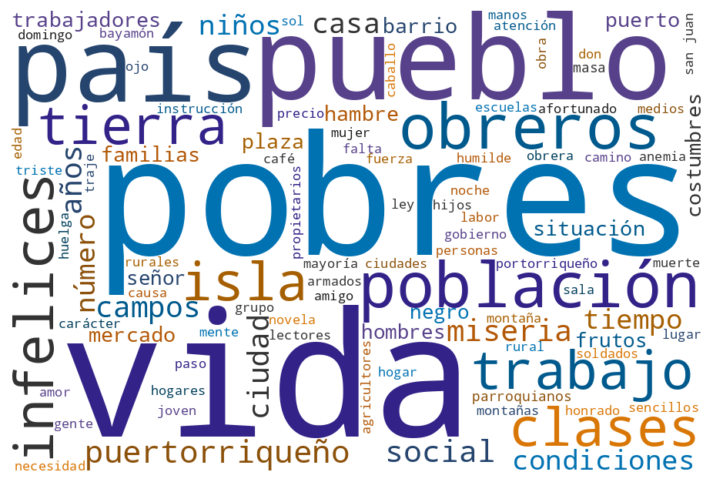

In [351]:
tfs = res['tfs']
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white',
    max_words=100,
    colormap=cmap
)
wc.generate_from_frequencies(tfs)
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()